# Low-Dimensional Performance Experimant

Test MoLA against traditional CDMs on the low-dimensional fraction-subtraction dataset on various performance metrics.

In [1]:
%load_ext autoreload
%autoreload

In [2]:
# Allows import of modules from src/ in root
%cd ..

/Users/marialentini/Projects/mixture-of-latent-archetypes


/Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Prepare Datasets

Download the fraction-subtraction dataset. Generate random train/test splits.

In [3]:
from src.utils.datasets import download_frac_subtr_to_pandas
import rpy2.robjects as ro

# Download fraction-subtraction datasets
X_df = download_frac_subtr_to_pandas('fraction.subtraction.data')
Q_df = download_frac_subtr_to_pandas('fraction.subtraction.qmatrix')

from sklearn.model_selection import ShuffleSplit
ss = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)

splits = []
for train_idx, test_idx in ss.split(X_df):
    X_train_df = X_df.iloc[train_idx]
    X_test_df = X_df.iloc[test_idx]
    splits.append((X_train_df, X_test_df))

# Get the citation object
citation = ro.r('citation("CDM")')
citation = ro.r('toBibtex(citation("CDM"))')

/Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Error importing in API mode: ImportError("dlopen(/Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <3C299107-E46F-31BA-AFE1-EA0CB28E5C55> /Users/marialentini/Projects/mixture-of-latent-archetypes/.venv/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


## Run Experiment

Train CDMs (DINA, GDINA and HO-DINA) and MoLA on all train/test splits.
MoLA's number of archetypes $M$ is selected per split by held-out
predictive log-likelihood (`select_mola_m`), the same model-selection
protocol used for the high-dimensional experiment: for each split, a
20% slice of that split's training learners is held out to score
candidate $M$ values from `M_GRID`, and the selected $M$ is then used to
refit MoLA on the *full* training set for that split -- the held-out
slice only ever informs which $M$ to use, never the final fitted
parameters.

In [4]:
import pandas as pd
import numpy as np
from src.experiments.low_dim import fit_mola, run_experiment

In [5]:
%%capture
M_GRID = [2, 4, 6, 8, 10, 12, 14]

final_results = []

# Fit classical CDMs
for model_name in ["DINA", "GDINA", "HO-DINA"]:
    result = run_experiment(model_name, splits, Q_df)
    final_results.append(result)

# Fit MoLA, selecting M per split from M_GRID
result = fit_mola(splits, Q_df, m_grid=M_GRID)
final_results += result

## Compile Results Table

Saves results to results/ folder in `low-dim-results.csv`.

In [6]:
results_df = pd.DataFrame([
    {
        "Model": result['model'],
        "auc_train": np.mean(result['auc_train']),
        "Test AUC": np.mean(result['auc_test']),
        "nll_train": np.mean(result['nll_train']),
        "Test NLL": np.mean(result['nll_test']),
        "brier_train": np.mean(result['brier_train']),
        "Test Brier": np.mean(result['brier_test'])
    } 
    for result in final_results
]).set_index("Model")

results_df.to_csv('./results/low-dim-results.csv')
print(results_df.to_latex(
    float_format="%.3f",
    caption="Mean training and test-set AUC, NLL, and Brier score for each model on the "
            "fraction-subtraction dataset, averaged across 100 train/test splits.",
    label="tab:lowdim_results",
))
results_df.round(3)

\begin{table}
\caption{Mean training and test-set AUC, NLL, and Brier score for each model on the fraction-subtraction dataset, averaged across 100 train/test splits.}
\label{tab:lowdim_results}
\begin{tabular}{lrrrrrr}
\toprule
 & auc_train & Test AUC & nll_train & Test NLL & brier_train & Test Brier \\
Model &  &  &  &  &  &  \\
\midrule
DINA & 0.899 & 0.893 & 0.405 & 0.414 & 0.128 & 0.131 \\
GDINA & 0.925 & 0.904 & 0.336 & 0.382 & 0.104 & 0.118 \\
HO-DINA & 0.912 & 0.903 & 0.361 & 0.379 & 0.111 & 0.117 \\
MoLA & 0.916 & 0.902 & 0.364 & 0.392 & 0.112 & 0.122 \\
\bottomrule
\end{tabular}
\end{table}



,auc_train,Test AUC,nll_train,Test NLL,brier_train,Test Brier
Model,,,,,,
DINA,0.899,0.893,0.405,0.414,0.128,0.131
GDINA,0.925,0.904,0.336,0.382,0.104,0.118
HO-DINA,0.912,0.903,0.361,0.379,0.111,0.117
MoLA,0.916,0.902,0.364,0.392,0.112,0.122


In [7]:
mola_result = [r for r in final_results if r["model"] == "MoLA"][0]
selected_m_counts = pd.Series(mola_result["selected_m"]).value_counts().sort_index()
selected_m_counts.index.name = "Selected M"
selected_m_counts.name = "# Splits (of 100)"

print(selected_m_counts.to_latex(
    caption="Distribution of MoLA's selected number of archetypes $M$ across the 100 train/test "
            f"splits, chosen from M\\_GRID={M_GRID} by held-out predictive log-likelihood.",
    label="tab:lowdim_selected_m",
))
selected_m_counts


\begin{table}
\caption{Distribution of MoLA's selected number of archetypes $M$ across the 100 train/test splits, chosen from M\_GRID=[2, 4, 6, 8, 10, 12, 14] by held-out predictive log-likelihood.}
\label{tab:lowdim_selected_m}
\begin{tabular}{lr}
\toprule
 & # Splits (of 100) \\
Selected M &  \\
\midrule
4 & 4 \\
6 & 23 \\
8 & 19 \\
10 & 15 \\
12 & 20 \\
14 & 19 \\
\bottomrule
\end{tabular}
\end{table}



Selected M
4      4
6     23
8     19
10    15
12    20
14    19
Name: # Splits (of 100), dtype: int64

## Is the Gap Between MoLA and the Classical CDMs Statistically Significant?

The table above reports only mean test-set metrics across the 100
`ShuffleSplit` train/test resamples. Comparing means, or their spread via
a pooled standard deviation, does not establish whether a difference is
statistically significant, and in particular does not establish that two
models are "comparable" or equivalent.

MoLA and each classical CDM baseline (DINA, GDINA, HO-DINA) are fit and
evaluated on the *same* 100 splits, in the same order (`final_results`),
so this is a paired comparison. It is *not*, however, a comparison of
100 independent paired observations: `ShuffleSplit`'s 100 splits are
repeated random resamples of the same 536 learners, so every split's
~430-learner training set overlaps heavily with every other split's --
and since `ShuffleSplit` draws its test set independently each time
(unlike k-fold CV's disjoint folds), the same learner can also land in
many splits' *test* sets. Both effects correlate the per-split metric
values across splits. A plain paired test (a t-test, or the paired
bootstrap used for the high-dimensional experiment) treats the 100
splits as independent and so *underestimates* the variance of the mean
difference, inflating the false-positive rate -- confirmed directly:
several comparisons that looked significant under a naive paired
bootstrap were not once corrected for this (see the design discussion
that produced this cell).

We instead use the corrected resampled paired t-test of Nadeau & Bengio
(2003) (`nadeau_bengio_test`), purpose-built for exactly this repeated
random train/test resampling scenario. It replaces the naive
variance-of-the-mean term `1/n` with `1/n + n_test/n_train` -- always
larger, since `n_test/n_train > 0` -- which inflates the estimated
variance to account for the overlap-induced correlation. With this
dataset's 80/20 split, `n_test/n_train = 108/428 \approx 0.25`, roughly
25x the naive `1/n = 0.01` term, so this correction is not a minor
technicality here.

One detail worth stating precisely: the held-out item mask used to score
each split (`get_y_proba_and_true`) reseeds to a fixed value
(`np.random.seed(254)`) immediately before every draw, and every split's
train/test arrays have the same shape -- so the mask pattern is
identical across all 100 splits. This does not affect the correction
above (which addresses train/test *learner* overlap, not the item
mask), but is worth keeping in mind alongside it.

We report only MoLA vs. each of the three classical baselines (3
comparisons per metric, not all $\binom{4}{2}=6$ pairs among the four
models), since the baseline-vs-baseline comparisons aren't a claim this
paper makes. Because three comparisons are tested simultaneously per
metric, we apply a Holm-Bonferroni correction across them ($\alpha =
0.05$) rather than treating each in isolation. A comparison surviving
this correction supports a claim of a significant difference (negative
`MoLA - Baseline` favors MoLA for NLL and Brier score, positive favors
MoLA for AUC); failing to survive it supports only "no significant
difference detected at this sample size," not equivalence.


In [8]:
from src.simulations.metrics import nadeau_bengio_test, holm_bonferroni

baseline_names = ["DINA", "GDINA", "HO-DINA"]
metrics_map = {"nll_test": "NLL", "brier_test": "Brier Score", "auc_test": "AUC"}

results_by_model = {result["model"]: result for result in final_results}
mola_result = results_by_model["MoLA"]

n_train, n_test = len(splits[0][0]), len(splits[0][1])

rows = []
for metric_key, metric_label in metrics_map.items():
    comparisons = []
    for baseline in baseline_names:
        stat = nadeau_bengio_test(
            np.array(mola_result[metric_key]), np.array(results_by_model[baseline][metric_key]),
            n_train=n_train, n_test=n_test,
        )
        comparisons.append((baseline, stat))

    p_values = [stat["p_value"] for _, stat in comparisons]
    holm_significant = holm_bonferroni(p_values, alpha=0.05)

    for (baseline, stat), sig in zip(comparisons, holm_significant):
        rows.append({
            "Metric": metric_label,
            "Baseline": baseline,
            "n": stat["n"],
            "MoLA - Baseline": stat["point_diff"],
            "95% CI": f"[{stat['ci_lo']:.4f}, {stat['ci_hi']:.4f}]",
            "p-value": stat["p_value"],
            "Significant (Holm)": "yes" if sig else "no",
        })

comparison_df = pd.DataFrame(rows).set_index(["Metric", "Baseline"])
print(comparison_df.to_latex(
    float_format="%.4f",
    caption="Nadeau-Bengio corrected paired $t$-test comparisons of MoLA against each classical CDM "
            "baseline on the fraction-subtraction dataset, paired by train/test split and corrected "
            "for the train/test overlap induced by repeated \\texttt{ShuffleSplit} resampling. "
            "\\texttt{Significant} marks comparisons surviving Holm-Bonferroni correction across the "
            "3 baselines within each metric ($\\alpha=0.05$).",
    label="tab:lowdim_paired_comparison",
))
comparison_df


\begin{table}
\caption{Nadeau-Bengio corrected paired $t$-test comparisons of MoLA against each classical CDM baseline on the fraction-subtraction dataset, paired by train/test split and corrected for the train/test overlap induced by repeated \texttt{ShuffleSplit} resampling. \texttt{Significant} marks comparisons surviving Holm-Bonferroni correction across the 3 baselines within each metric ($\alpha=0.05$).}
\label{tab:lowdim_paired_comparison}
\begin{tabular}{llrrlrl}
\toprule
 &  & n & MoLA - Baseline & 95% CI & p-value & Significant (Holm) \\
Metric & Baseline &  &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{NLL} & DINA & 100 & -0.0223 & [-0.0428, -0.0018] & 0.0332 & no \\
 & GDINA & 100 & 0.0091 & [-0.0117, 0.0300] & 0.3871 & no \\
 & HO-DINA & 100 & 0.0127 & [-0.0058, 0.0311] & 0.1768 & no \\
\cline{1-7}
\multirow[t]{3}{*}{Brier Score} & DINA & 100 & -0.0084 & [-0.0159, -0.0009] & 0.0293 & no \\
 & GDINA & 100 & 0.0046 & [-0.0019, 0.0112] & 0.1651 & no \\
 & HO-DINA & 100 & 0.0057 

n  MoLA - Baseline              95% CI   p-value  \
Metric      Baseline                                                       
NLL         DINA      100        -0.022310  [-0.0428, -0.0018]  0.033247   
            GDINA     100         0.009121   [-0.0117, 0.0300]  0.387080   
            HO-DINA   100         0.012659   [-0.0058, 0.0311]  0.176830   
Brier Score DINA      100        -0.008385  [-0.0159, -0.0009]  0.029347   
            GDINA     100         0.004628   [-0.0019, 0.0112]  0.165105   
            HO-DINA   100         0.005678   [-0.0012, 0.0125]  0.102580   
AUC         DINA      100         0.009044   [-0.0018, 0.0199]  0.100679   
            GDINA     100        -0.002488   [-0.0117, 0.0067]  0.593800   
            HO-DINA   100        -0.001043   [-0.0111, 0.0090]  0.837308   

                     Significant (Holm)  
Metric      Baseline                     
NLL         DINA                     no  
            GDINA                    no  
            HO-DINA                  no  
Brier Score DINA                     no  
            GDINA                    no  
            HO-DINA                  no  
AUC         DINA                     no  
            GDINA                    no  
            HO-DINA                  no

In [9]:
def _fmt_bootstrap_cell(diff: float, significant: bool) -> str:
    formatted = f"{diff:.4f}"
    return f"$\\mathbf{{{formatted}}}$" if significant else f"${formatted}$"

metric_order = ["NLL", "Brier Score", "AUC"]

lines = [
    r"\begin{table}",
    r"\center",
    r"\caption{Paired differences in performance between MoLA and each classical CDM baseline "
    r"on the fraction-subtraction dataset (100 train/test splits), via the Nadeau-Bengio corrected "
    r"paired $t$-test. Entries report MoLA $-$ Baseline; "
    r"negative values favor MoLA for NLL and Brier score, whereas positive values favor MoLA for AUC. "
    r"Bold values indicate that the comparison is significant after Holm-Bonferroni correction across "
    r"the 3 baselines within each metric ($\alpha=0.05$).}",
    r"\label{tab:lowdim_paired_comparison}",
    r"\begin{tabular}{l" + "r" * len(metric_order) + "}",
    r"\toprule",
    "Baseline & " + " & ".join(metric_order) + r" \\",
    r"\midrule",
]
for baseline in baseline_names:
    cells = [
        _fmt_bootstrap_cell(
            comparison_df.loc[(metric_label, baseline), "MoLA - Baseline"],
            comparison_df.loc[(metric_label, baseline), "Significant (Holm)"] == "yes",
        )
        for metric_label in metric_order
    ]
    lines.append(f"{baseline} & " + " & ".join(cells) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

print("\n".join(lines))


\begin{table}
\center
\caption{Paired differences in performance between MoLA and each classical CDM baseline on the fraction-subtraction dataset (100 train/test splits), via the Nadeau-Bengio corrected paired $t$-test. Entries report MoLA $-$ Baseline; negative values favor MoLA for NLL and Brier score, whereas positive values favor MoLA for AUC. Bold values indicate that the comparison is significant after Holm-Bonferroni correction across the 3 baselines within each metric ($\alpha=0.05$).}
\label{tab:lowdim_paired_comparison}
\begin{tabular}{lrrr}
\toprule
Baseline & NLL & Brier Score & AUC \\
\midrule
DINA & $-0.0223$ & $-0.0084$ & $0.0090$ \\
GDINA & $0.0091$ & $0.0046$ & $-0.0025$ \\
HO-DINA & $0.0127$ & $0.0057$ & $-0.0010$ \\
\bottomrule
\end{tabular}
\end{table}


## Visualize Callibration

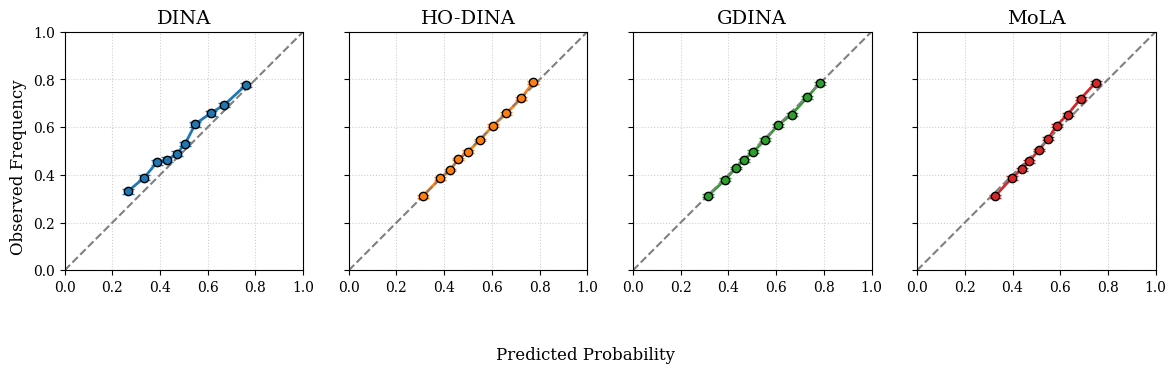

In [10]:
from src.experiments.low_dim import plot_calibrations

model_names = ["DINA", "HO-DINA", "GDINA", "MoLA"]
plot_calibrations(final_results, model_names, n_bins=10)